
Verarbeite: Messung 1.dat
Datenpunkte: 2642


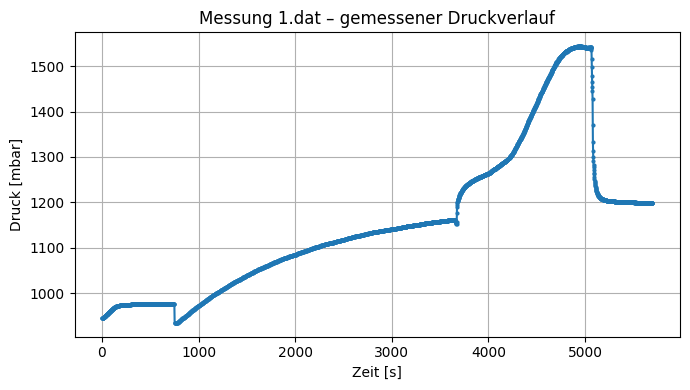

p_inf = 1199.95 mbar
k (ln-Plot) = 6.7124e-04 1/s


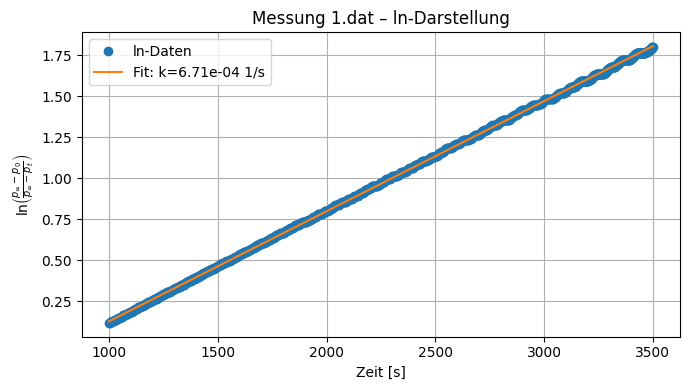


Verarbeite: Messung 2.dat
Datenpunkte: 952


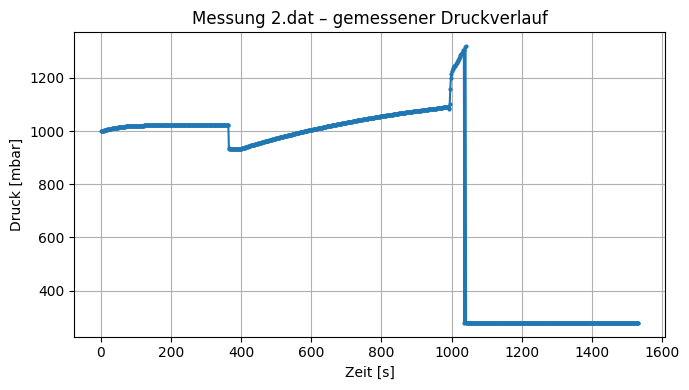

k (Fit) = 1.5663e-03 ± 9.15e-06 1/s


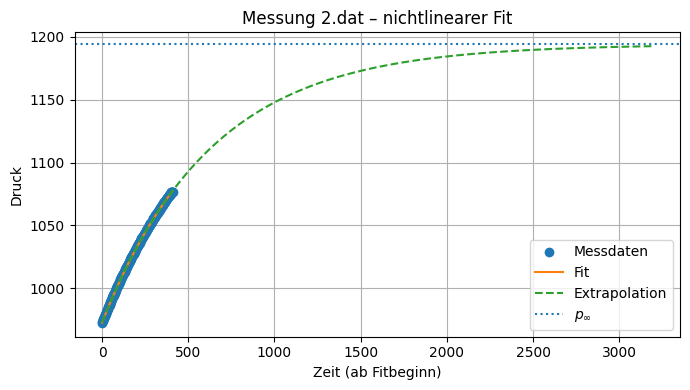


Verarbeite: Messung 3,1.dat
Datenpunkte: 295


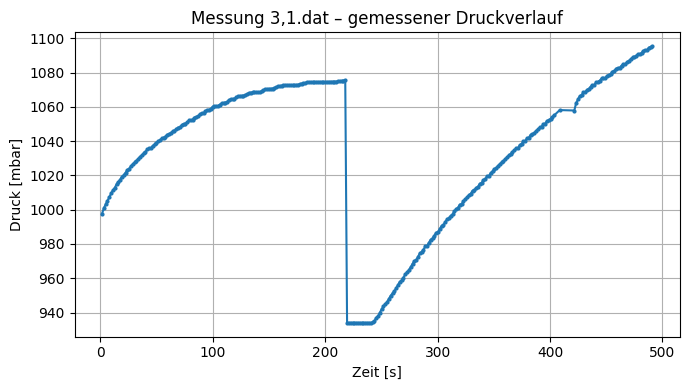

k (Fit) = 3.8936e-03 ± 4.94e-05 1/s


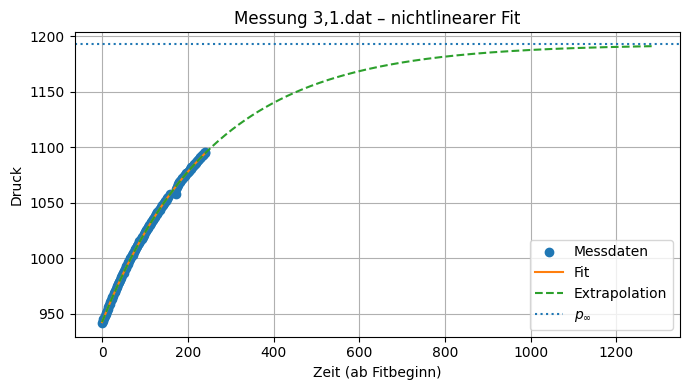

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================================================
# Modellfunktion
# =========================================================
def p_model(t, p_inf, p0, k):
    return p_inf - (p_inf - p0) * np.exp(-k * t)

# =========================================================
# Konfiguration der Messungen
# =========================================================
cfg = {
    "Messung 1.dat": {
        "type": "ln",
        "plateau_start": 5300,
        "ln_fit_min": 1000,
        "ln_fit_max": 3500,
    },
    "Messung 2.dat": {
        "type": "nonlinear",
        "fit_min": 500,
        "fit_max": 910,
    },
    "Messung 3,1.dat": {
        "type": "nonlinear",
        "fit_min": 250,
        "fit_max": 500,
    },
}

# =========================================================
# Schleife über alle Messungen
# =========================================================
for fname, c in cfg.items():
    print("\n" + "="*60)
    print("Verarbeite:", fname)

    # -----------------------------
    # Daten einlesen
    # -----------------------------
    df = pd.read_csv(
        fname,
        sep=r"\s+",
        decimal=",",
        header=None,
        names=["Zeit", "Druck"],
        engine="python"
    ).dropna()

    print(f"Datenpunkte: {len(df)}")

    # =====================================================
    # 1️⃣ IMMER: kompletter Messgraph
    # =====================================================
    plt.figure(figsize=(7,4))
    plt.plot(df["Zeit"], df["Druck"], "o-", markersize=2)
    plt.xlabel("Zeit [s]")
    plt.ylabel("Druck [mbar]")
    plt.title(f"{fname} – gemessener Druckverlauf")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # =====================================================
    # 2️⃣ Messung 1 → ln-Plot
    # =====================================================
    if c["type"] == "ln":
        plateau_start = c["plateau_start"]

        df_plateau = df[df["Zeit"] >= plateau_start]
        p_inf = df_plateau["Druck"].mean()
        print(f"p_inf = {p_inf:.2f} mbar")

        p0 = df["Druck"].iloc[0]

        df_lin = df[df["Zeit"] < plateau_start].copy()
        df_lin = df_lin[df_lin["Druck"] < p_inf]
        df_lin["ln_term"] = np.log((p_inf - p0) / (p_inf - df_lin["Druck"]))

        df_fit = df_lin[
            (df_lin["Zeit"] >= c["ln_fit_min"]) &
            (df_lin["Zeit"] <= c["ln_fit_max"])
        ]

        k, b = np.polyfit(df_fit["Zeit"], df_fit["ln_term"], 1)
        print(f"k (ln-Plot) = {k:.4e} 1/s")

        t_line = np.linspace(c["ln_fit_min"], c["ln_fit_max"], 200)
        ln_line = k * t_line + b

        plt.figure(figsize=(7,4))
        plt.plot(df_fit["Zeit"], df_fit["ln_term"], "o", label="ln-Daten")
        plt.plot(t_line, ln_line, "-", label=f"Fit: k={k:.2e} 1/s")
        plt.xlabel("Zeit [s]")
        plt.ylabel(r"$\ln\!\left(\frac{p_\infty-p_0}{p_\infty-p_t}\right)$")
        plt.title(f"{fname} – ln-Darstellung")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # =====================================================
    # 3️⃣ Messung 2 & 3 → nichtlinearer Fit
    # =====================================================
    else:
        t = df["Zeit"].to_numpy()
        p = df["Druck"].to_numpy()

        mask = (t >= c["fit_min"]) & (t <= c["fit_max"])
        t_fit = t[mask]
        p_fit = p[mask]

        t0 = t_fit[0]
        tt = t_fit - t0

        popt, pcov = curve_fit(
            p_model,
            tt,
            p_fit,
            p0=[p_fit.max()*1.05, p_fit[0], 1e-3],
            bounds=([p_fit.max(), -np.inf, 0], [np.inf, np.inf, np.inf])
        )

        p_inf, p0_fit, k = popt
        k_err = np.sqrt(np.diag(pcov))[2]

        print(f"k (Fit) = {k:.4e} ± {k_err:.2e} 1/s")

        tau = 1 / k
        t_ext = np.linspace(0, 5*tau, 500)
        p_ext = p_model(t_ext, *popt)

        plt.figure(figsize=(7,4))
        plt.plot(tt, p_fit, "o", label="Messdaten")
        plt.plot(tt, p_model(tt, *popt), "-", label="Fit")
        plt.plot(t_ext, p_ext, "--", label="Extrapolation")
        plt.axhline(p_inf, linestyle=":", label=r"$p_\infty$")
        plt.xlabel("Zeit (ab Fitbeginn)")
        plt.ylabel("Druck")
        plt.title(f"{fname} – nichtlinearer Fit")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


Verarbeite: Messung 1.dat
Datenpunkte: 2642
p_inf (Plateau) = 1199.95 ± 0.82 mbar


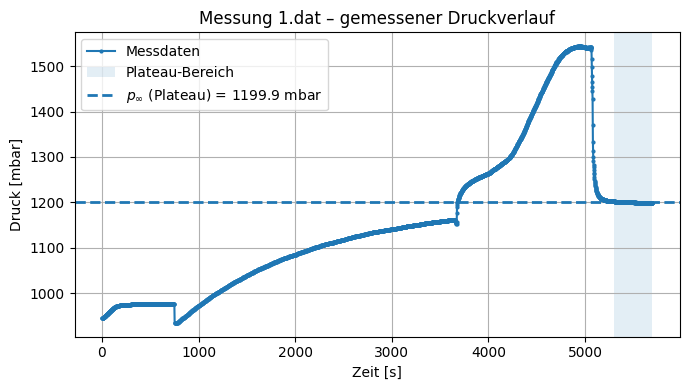

k (ln-Plot) = 6.7124e-04 1/s


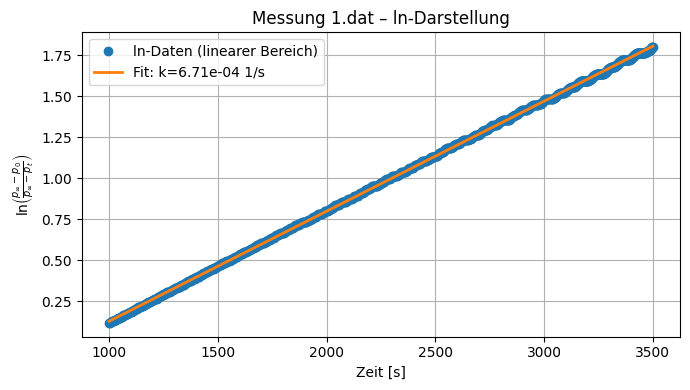


Verarbeite: Messung 2.dat
Datenpunkte: 952
p_inf (Plateau) = 467.33 ± 358.59 mbar


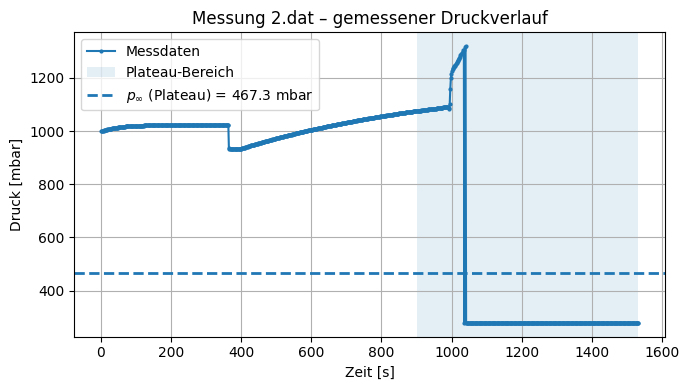

p_inf (Fit) = 1187.38 mbar
k (Fit)     = 1.6311e-03 ± 4.35e-06 1/s


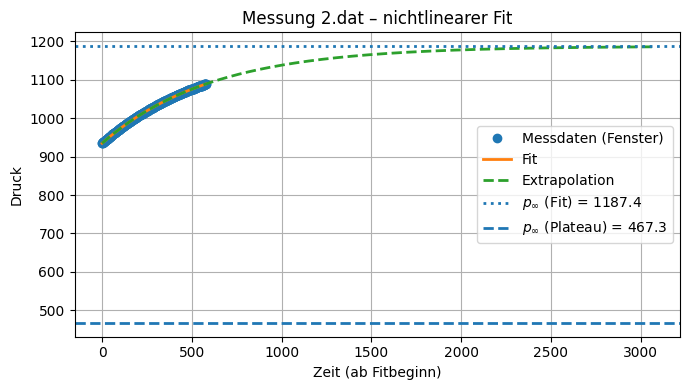


Verarbeite: Messung 3,1.dat
Datenpunkte: 295
p_inf (Plateau) = 1093.58 ± 1.45 mbar


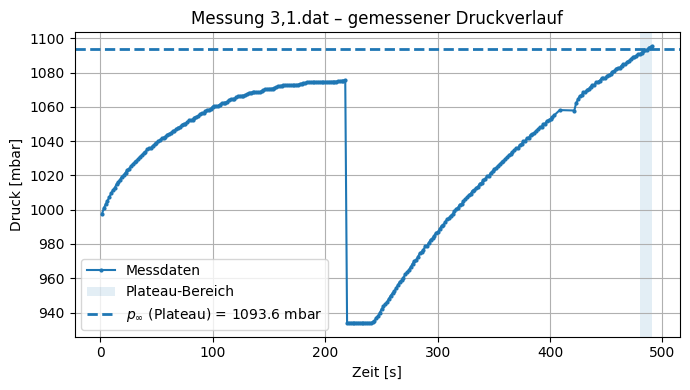

p_inf (Fit) = 1192.77 mbar
k (Fit)     = 3.8936e-03 ± 4.94e-05 1/s


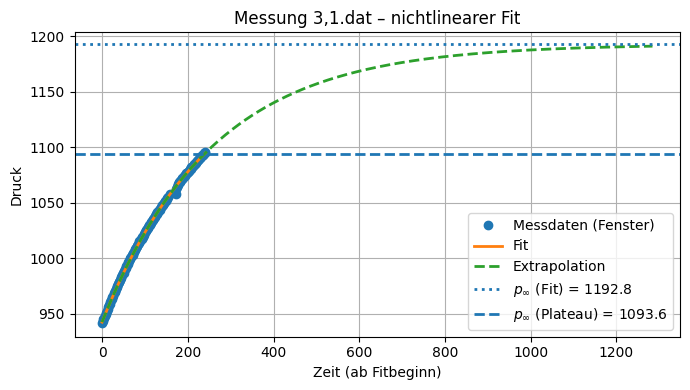


Arrhenius-Auswertung
E_A = 71.57 kJ/mol
ln(A) = 21.09


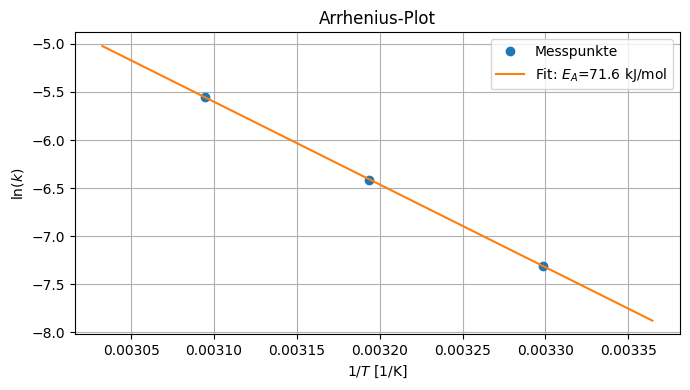

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# =========================================================
# Modellfunktion
# =========================================================
def p_model(t, p_inf, p0, k):
    return p_inf - (p_inf - p0) * np.exp(-k * t)

# =========================================================
# Konfiguration der Messungen
# -> plateau_start / plateau_end: p_inf aus Plateau bestimmen
# =========================================================
cfg = {
    "Messung 1.dat": {
        "type": "ln",
        "plateau_start": 5300,
        "plateau_end": None,
        "ln_fit_min": 1000,
        "ln_fit_max": 3500,
        "T_C": 30,
    },
    "Messung 2.dat": {
        "type": "nonlinear",
        "fit_min": 400,
        "fit_max": 980,
        "plateau_start": 900,      # <<< HIER anpassen (Plateau bei Messung 2)
        "plateau_end": None,
        "T_C": 40,
    },
    "Messung 3,1.dat": {
        "type": "nonlinear",
        "fit_min": 250,
        "fit_max": 500,
        "plateau_start": 480,      # <<< HIER anpassen (Plateau bei Messung 3)
        "plateau_end": None,
        "T_C": 50,
    },
}

# =========================================================
# Sammel-Listen für Arrhenius
# =========================================================
T_list = []
k_list = []

# =========================================================
# Schleife über alle Messungen
# =========================================================
for fname, c in cfg.items():
    print("\n" + "="*60)
    print("Verarbeite:", fname)

    # -----------------------------
    # Daten einlesen
    # -----------------------------
    df = pd.read_csv(
        fname,
        sep=r"\s+",
        decimal=",",
        header=None,
        names=["Zeit", "Druck"],
        engine="python"
    ).dropna()

    print(f"Datenpunkte: {len(df)}")

    # =====================================================
    # p_inf aus Plateau (für ALLE Messungen)
    # =====================================================
    p_inf_plateau = None
    p_inf_plateau_std = None

    if "plateau_start" in c and c["plateau_start"] is not None:
        t_ps = c["plateau_start"]
        t_pe = c.get("plateau_end", None)

        if t_pe is None:
            df_plateau = df[df["Zeit"] >= t_ps].copy()
        else:
            df_plateau = df[(df["Zeit"] >= t_ps) & (df["Zeit"] <= t_pe)].copy()

        if df_plateau.empty:
            raise ValueError(f"❌ Plateau-Bereich leer bei {fname}. plateau_start/plateau_end anpassen.")

        p_inf_plateau = df_plateau["Druck"].mean()
        p_inf_plateau_std = df_plateau["Druck"].std()

        print(f"p_inf (Plateau) = {p_inf_plateau:.2f} ± {p_inf_plateau_std:.2f} mbar")

    # =====================================================
    # 1️⃣ IMMER: kompletter Messgraph + p_inf Plateau Linie
    # =====================================================
    plt.figure(figsize=(7,4))
    plt.plot(df["Zeit"], df["Druck"], "o-", markersize=2, label="Messdaten")

    if p_inf_plateau is not None:
        t_ps = c["plateau_start"]
        t_pe_plot = df["Zeit"].max() if c.get("plateau_end", None) is None else c["plateau_end"]

        plt.axvspan(t_ps, t_pe_plot, alpha=0.12, label="Plateau-Bereich")
        plt.axhline(p_inf_plateau, linestyle="--", linewidth=2,
                    label=f"$p_\\infty$ (Plateau) = {p_inf_plateau:.1f} mbar")

    plt.xlabel("Zeit [s]")
    plt.ylabel("Druck [mbar]")
    plt.title(f"{fname} – gemessener Druckverlauf")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =====================================================
    # 2️⃣ Messung 1 → ln-Plot (k aus Steigung)
    # =====================================================
    if c["type"] == "ln":
        if p_inf_plateau is None:
            raise ValueError("Für ln-Methode brauchst du p_inf aus Plateau. plateau_start setzen!")

        p_inf = p_inf_plateau
        p0 = df["Druck"].iloc[0]

        plateau_start = c["plateau_start"]
        df_lin = df[df["Zeit"] < plateau_start].copy()
        df_lin = df_lin[df_lin["Druck"] < p_inf].copy()
        df_lin["ln_term"] = np.log((p_inf - p0) / (p_inf - df_lin["Druck"]))

        df_fit = df_lin[
            (df_lin["Zeit"] >= c["ln_fit_min"]) &
            (df_lin["Zeit"] <= c["ln_fit_max"])
        ].copy()

        if df_fit.empty:
            raise ValueError(f"ln-Fit-Bereich leer bei {fname}. ln_fit_min/ln_fit_max anpassen.")

        k, b = np.polyfit(df_fit["Zeit"], df_fit["ln_term"], 1)
        print(f"k (ln-Plot) = {k:.4e} 1/s")

        T_list.append(c["T_C"] + 273.15)
        k_list.append(k)

        t_line = np.linspace(c["ln_fit_min"], c["ln_fit_max"], 200)
        ln_line = k * t_line + b

        plt.figure(figsize=(7,4))
        plt.plot(df_fit["Zeit"], df_fit["ln_term"], "o", label="ln-Daten (linearer Bereich)")
        plt.plot(t_line, ln_line, "-", linewidth=2, label=f"Fit: k={k:.2e} 1/s")
        plt.xlabel("Zeit [s]")
        plt.ylabel(r"$\ln\!\left(\frac{p_\infty-p_0}{p_\infty-p_t}\right)$")
        plt.title(f"{fname} – ln-Darstellung")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    # =====================================================
    # 3️⃣ Messung 2 & 3 → nichtlinearer Fit (k aus Fit)
    # =====================================================
    else:
        t = df["Zeit"].to_numpy()
        p = df["Druck"].to_numpy()

        mask = (t >= c["fit_min"]) & (t <= c["fit_max"])
        t_fit = t[mask]
        p_fit = p[mask]

        if len(t_fit) < 5:
            raise ValueError(f"Zu wenige Punkte im Fitfenster bei {fname}. fit_min/fit_max anpassen.")

        t0 = t_fit[0]
        tt = t_fit - t0

        popt, pcov = curve_fit(
            p_model,
            tt,
            p_fit,
            p0=[p_fit.max()*1.05, p_fit[0], 1e-3],
            bounds=([p_fit.max(), -np.inf, 0], [np.inf, np.inf, np.inf])
        )

        p_inf_fit, p0_fit, k = popt
        k_err = np.sqrt(np.diag(pcov))[2]

        print(f"p_inf (Fit) = {p_inf_fit:.2f} mbar")
        print(f"k (Fit)     = {k:.4e} ± {k_err:.2e} 1/s")

        T_list.append(c["T_C"] + 273.15)
        k_list.append(k)

        # Extrapolation bis 5*tau
        tau = 1 / k
        t_ext = np.linspace(0, 5*tau, 500)
        p_ext = p_model(t_ext, *popt)

        plt.figure(figsize=(7,4))
        plt.plot(tt, p_fit, "o", label="Messdaten (Fenster)")
        plt.plot(tt, p_model(tt, *popt), "-", linewidth=2, label="Fit")
        plt.plot(t_ext, p_ext, "--", linewidth=2, label="Extrapolation")

        # Linien: Plateau-p_inf (falls vorhanden) UND Fit-p_inf
        plt.axhline(p_inf_fit, linestyle=":", linewidth=2, label=f"$p_\\infty$ (Fit) = {p_inf_fit:.1f}")
        if p_inf_plateau is not None:
            plt.axhline(p_inf_plateau, linestyle="--", linewidth=2, label=f"$p_\\infty$ (Plateau) = {p_inf_plateau:.1f}")

        plt.xlabel("Zeit (ab Fitbeginn)")
        plt.ylabel("Druck")
        plt.title(f"{fname} – nichtlinearer Fit")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

# =========================================================
# 4️⃣ Arrhenius-Plot: ln(k) gegen 1/T
# =========================================================
T = np.array(T_list, dtype=float)  # Kelvin
k = np.array(k_list, dtype=float)  # 1/s

x = 1 / T
y = np.log(k)

m, b = np.polyfit(x, y, 1)

R = 8.314  # J/(mol*K)
E_A_kJ = (-m * R) / 1000

print("\n" + "="*60)
print("Arrhenius-Auswertung")
print(f"E_A = {E_A_kJ:.2f} kJ/mol")
print(f"ln(A) = {b:.2f}")

x_fit = np.linspace(x.min()*0.98, x.max()*1.02, 200)
y_fit = m * x_fit + b

plt.figure(figsize=(7,4))
plt.plot(x, y, "o", label="Messpunkte")
plt.plot(x_fit, y_fit, "-", label=f"Fit: $E_A$={E_A_kJ:.1f} kJ/mol")
plt.xlabel(r"$1/T$ [1/K]")
plt.ylabel(r"$\ln(k)$")
plt.title("Arrhenius-Plot")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()